# Vol Surface & Greeks

---

Introduce two class variables in Pricer that store the finite difference method (forward, backward, central) to be used in numerical greek calculation, and whether the bump size is absolute or relative.

Create two Enums to store the labels. Implement all combinations for delta and gamma calculation.

Compare greeks using the analytic and the finite difference methods on a set of European options and visualize the numerical error.

Compare absolute and relative bumping and suggest optimal bump sizes.

## Imports

In [1]:
import sys
from pathlib import Path
current = Path().resolve()
sys.path.append(str(current))

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from enums import *
from contract import *
from model import *
from pricer import *

MarketData.initialize()

## New class variables in Pricer

In [2]:
# class-level defaults
print("Default finite_method:", Pricer.finite_method)
print("Default bump_size_method:", Pricer.bump_size_method)

Default finite_method: FiniteMethod.CENTRAL
Default bump_size_method: BumpSizeMethod.RELATIVE


## All 6 FD combinations for delta & gamma

| Combination | Delta formula               | Gamma formula                   |
|-------------|-----------------------------|---------------------------------|
| Forward     | $(V(S+h)-V(S))/h$           | $(V(S+2h)-2V(S+h)+V(S))/h^2$    |
| Backward    | $(V(S)-V(S-h))/h$           | $(V(S)-2V(S-h)+V(S-2h))/h^2$    |
| Central     | $(V(S+h)-V(S-h))/(2h)$      | $(V(S+h)-2V(S)+V(S-h))/h^2$     |


h is either relative_bump_size × spot (RELATIVE) or relative_bump_size (ABSOLUTE).

In [4]:
und   = Stock.BLUECHIP_BANK
spot  = MarketData.get_spot()[und]
model = FlatVolModel(und)
call  = EuropeanContract(und, PutCallFwd.CALL, LongShort.LONG, spot, 1.0)
p_reference = EuropeanAnalyticPricer(call, model, Params())

delta_analytic = p_reference.calc_delta(GreekMethod.ANALYTIC)
gamma_analytic = p_reference.calc_gamma(GreekMethod.ANALYTIC)

print(f"{'FD Method':<12} {'BumpType':<12} {'Delta FD':>12} {'Delta Error':>12} {'Gamma FD':>12} {'Rho Error':>12}")
print("-" * 85)

for fm in FiniteMethod:
    for bm in BumpSizeMethod:
        p = EuropeanAnalyticPricer(call, copy.deepcopy(model), Params())
        p.finite_method = fm
        p.bump_size_method = bm
        delta = p.calc_delta(GreekMethod.BUMP)
        gamma = p.calc_gamma(GreekMethod.BUMP)
        print(f"{fm.value:<12} {bm.value:<12} {delta:>12.6f} {delta-delta_analytic:>12.2e} {gamma:>12.6f} {gamma-gamma_analytic:>12.2e}")

print()
print(f"{'Analytic':<25} {delta_analytic:>12.6f} {'—':>12} {gamma_analytic:>12.6f} {'—':>12}")


FD Method    BumpType         Delta FD  Delta Error     Gamma FD    Rho Error
-------------------------------------------------------------------------------------
FORWARD      RELATIVE         0.631106     4.94e-03     0.007500    -1.42e-04
FORWARD      ABSOLUTE         0.626201     3.82e-05     0.007641    -1.08e-06
BACKWARD     RELATIVE         0.621159    -5.00e-03     0.007782     1.40e-04
BACKWARD     ABSOLUTE         0.626125    -3.82e-05     0.007643     1.08e-06
CENTRAL      RELATIVE         0.626132    -3.06e-05     0.007642    -1.05e-07
CENTRAL      ABSOLUTE         0.626163    -1.81e-09     0.007642     1.81e-10

Analytic                      0.626163            —     0.007642            —


## Comparison of European options

Go over strikes and expiries for calls and puts and compute the absolute error between the analytic and the FD greeks for each FD method.

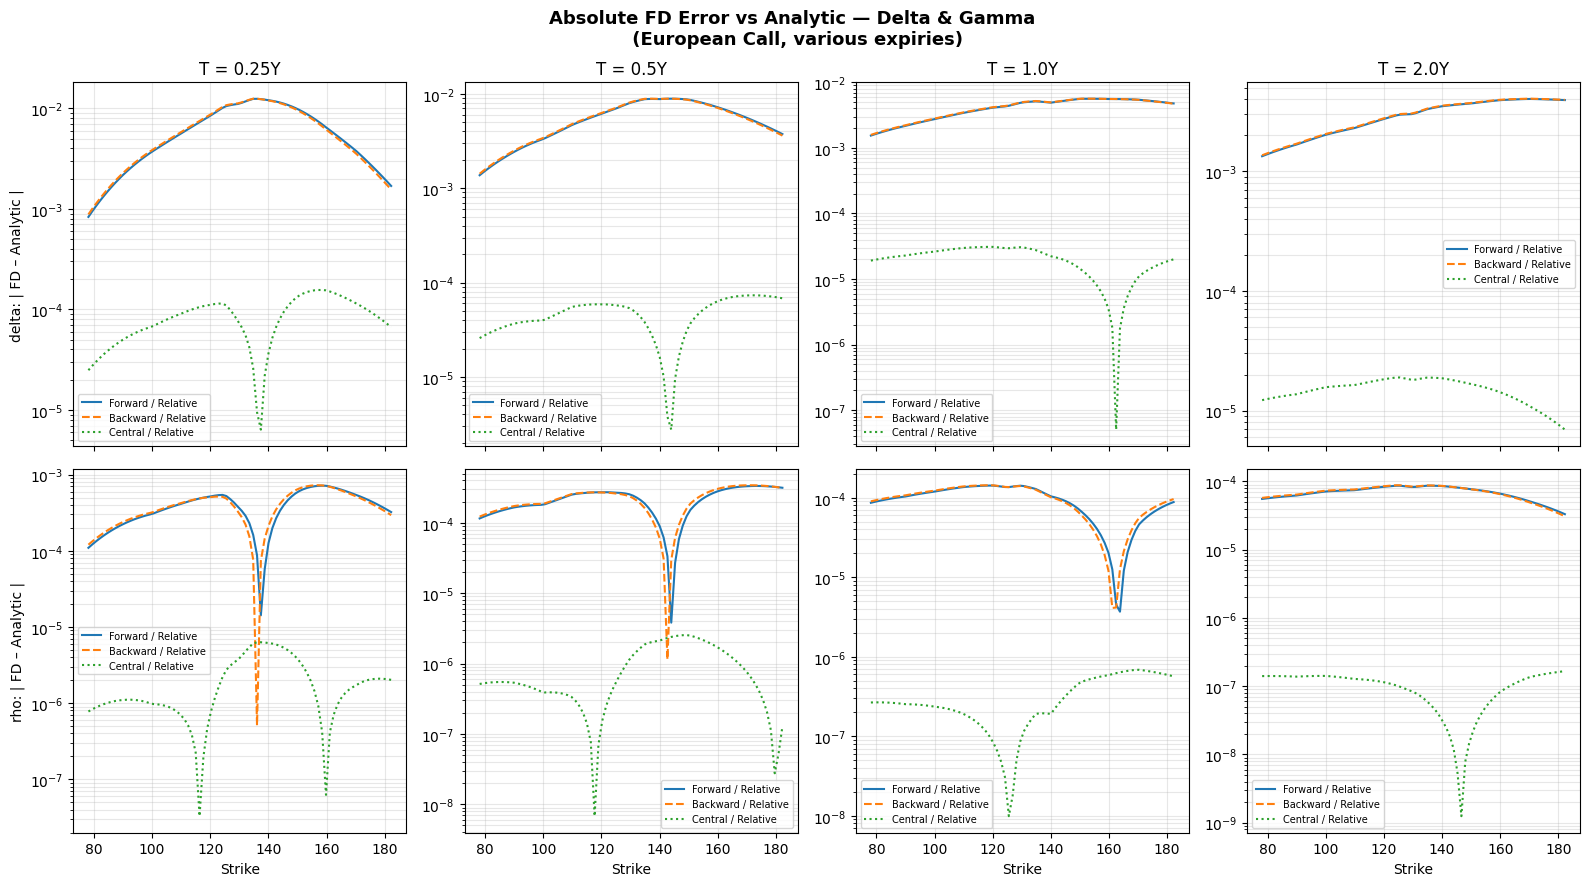

In [5]:
und = Stock.BLUECHIP_BANK
spot = MarketData.get_spot()[und]
strikes = np.linspace(0.6 * spot, 1.4 * spot, 80)
expiries = [0.25, 0.5, 1.0, 2.0]
put_calls = [PutCallFwd.CALL, PutCallFwd.PUT]

configs = [
    (FiniteMethod.FORWARD, BumpSizeMethod.RELATIVE, "Forward / Relative",  "C0", "-"),
    (FiniteMethod.BACKWARD, BumpSizeMethod.RELATIVE, "Backward / Relative", "C1", "--"),
    (FiniteMethod.CENTRAL, BumpSizeMethod.RELATIVE, "Central / Relative",  "C2", ":"),
]

fig, axes = plt.subplots(2, len(expiries), figsize=(16, 9), sharex=True)
fig.suptitle(
    "Absolute FD Error vs Analytic — Delta & Gamma \n (European Call, various expiries)",
    fontsize=13,
    fontweight="bold"
)

for col, T in enumerate(expiries):
    ax_d = axes[0, col]
    ax_g = axes[1, col]
    ax_d.set_title(f"T = {T}Y")
    ax_d.set_ylabel("delta: | FD – Analytic |") if col == 0 else None
    ax_g.set_ylabel("rho: | FD – Analytic |") if col == 0 else None
    ax_g.set_xlabel("Strike")

    for fm, bm, label, color, ls in configs:
        d_errs, g_errs = [], []
        for K in strikes:
            contract = EuropeanContract(und, PutCallFwd.CALL, LongShort.LONG, K, T)
            model = FlatVolModel(und)
            p_ref = EuropeanAnalyticPricer(contract, model, Params())
            da = p_ref.calc_delta(GreekMethod.ANALYTIC)
            ga = p_ref.calc_gamma(GreekMethod.ANALYTIC)

            p_fd = EuropeanAnalyticPricer(contract, copy.deepcopy(model), Params())
            p_fd.finite_method = fm
            p_fd.bump_size_method = bm
            d_errs.append(abs(p_fd.calc_delta(GreekMethod.BUMP) - da))
            g_errs.append(abs(p_fd.calc_gamma(GreekMethod.BUMP) - ga))

        ax_d.semilogy(strikes, d_errs, ls=ls, color=color, label=label)
        ax_g.semilogy(strikes, g_errs, ls=ls, color=color, label=label)

    for ax in (ax_d, ax_g):
        ax.grid(True, which="both", alpha=0.3)
        ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

## Absolute vs relative bump size

Evaluate the absolute FD error at an ATM option over a wide log-range of bump sizes using the central scheme.

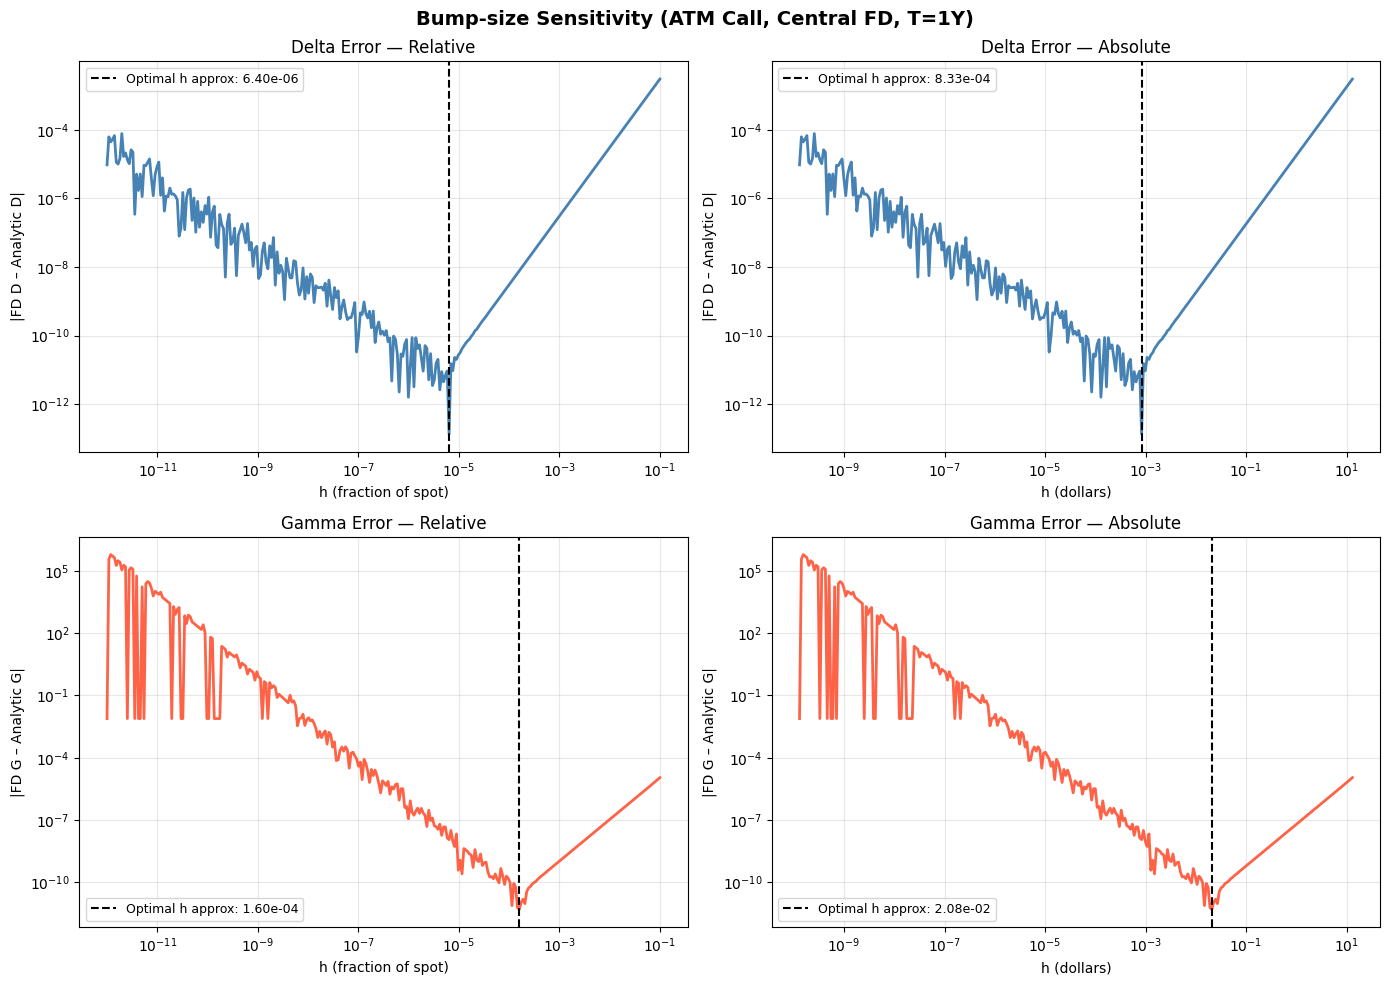

In [6]:
und  = Stock.BLUECHIP_BANK
spot = MarketData.get_spot()[und]
T    = 1.0
call = EuropeanContract(und, PutCallFwd.CALL, LongShort.LONG, spot, T)

p_ref = EuropeanAnalyticPricer(call, FlatVolModel(und), Params())
delta_true = p_ref.calc_delta(GreekMethod.ANALYTIC)
gamma_true = p_ref.calc_gamma(GreekMethod.ANALYTIC)

# Relative sweep: h as fraction of spot
h_rel = np.logspace(-12, -1, 300)
# Absolute sweep: h in dollar terms (equivalent range)
h_abs = spot * h_rel

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Bump-size Sensitivity (ATM Call, Central FD, T=1Y)", fontsize=14, fontweight="bold")

for col, (bm, h_arr, xlabel, pfx) in enumerate([
    (BumpSizeMethod.RELATIVE, h_rel, "h (fraction of spot)", "Relative"),
    (BumpSizeMethod.ABSOLUTE, h_abs, "h (dollars)", "Absolute"),
]):
    d_errs, g_errs = [], []
    for h in h_arr:
        p = EuropeanAnalyticPricer(call, FlatVolModel(und), Params())
        p.finite_method = FiniteMethod.CENTRAL
        p.bump_size_method = bm
        p.relative_bump_size = h  # reuse the field as the raw bump size
        d_errs.append(abs(p.calc_delta(GreekMethod.BUMP) - delta_true))
        g_errs.append(abs(p.calc_gamma(GreekMethod.BUMP) - gamma_true))

    for row, (err, greek, color) in enumerate([
        (d_errs, "Delta", "steelblue"),
        (g_errs, "Gamma", "tomato"),
    ]):
        ax = axes[row, col]
        ax.loglog(h_arr, err, color=color, lw=2)

        idx = np.nanargmin(err) # Return the indices of the minimum values
        ax.axvline(
            h_arr[idx], color="k", ls="--", lw=1.5, label=f"Optimal h approx: {h_arr[idx]:.2e}"
        )
        ax.set_title(f"{greek} Error — {pfx}")
        ax.set_xlabel(xlabel)
        ax.set_ylabel(f"|FD {greek[0]} – Analytic {greek[0]}|")
        ax.legend(fontsize=9)
        ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

## Recommendations

The error plots show that central differences produce the smallest absolute error across all strikes and expiries.

Forward and backward errors are similar in magnitude.

### Optimal bump sizes for an ATM call with Central FD and double precision:

| Greek | Optimal relative h | Optimal absolute h (at spot S) |
|---|--------------------|--------------------------------|
| Delta | 6.4e-6             | 8.33e-4                        |
| Gamma | 1.6e-4             | 2.08e-2                        |

---

## AI Usage

- Claude Sonnet 4.6. Extended thinking: for improving the visualizations.